# BoE_FinancialStability_SentimentAnalysis_v.2.ipynb [FG]

<div class="alert alert-block alert-info">
Notebook Start

# LSE | Bank of England | Financial Stability Reports Sentiment Analysis

This notebook analyses the tone and sentiment of the Bank of England Financial Stability Reports (1998–2022) using the Loughran–McDonald finance-specific dictionary.

**Purpose:**  
To measure changes in language tone over time (e.g., positive, negative, uncertainty, litigious, constraining, strong, weak) and compute comparable indicators across reports.

**Data Sources:**  
- PDF reports stored in `pdfs/financial_stability/`  
- Dictionary: `LSE_DA_BoE_Employer_project_Sentiment-labelled_wordlist-2-1.xlsx`

**Outputs:**  
- **Table 1: Document-level sentiment summary** - one row per report with all indicators
- **Table 2: Term-level matches** - term-level matches for auditability
- Visual trends over time

In [1]:
# !pip install pandas numpy pymupdf

import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

## Configuration

We place the notebook at the project root (same folder as the dictionary file).  

In [2]:
# --- Paths
PDF_FOLDER = Path("pdfs/financial_stability")   # your 50 FSR PDFs
DICT_XLSX  = Path("LSE_DA_BoE_Employer_project_Sentiment-labelled_wordlist-2-1.xlsx")
DICT_SHEET = "Loughran-McDonald_MasterDiction"
OUT_DIR    = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Presentation options
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

## Load the LM dictionary

We use the columns: `Word`, and binary flags for `Negative, Positive, Uncertainty, Litigious, Strong, Weak, Constraining`.  
We lower-case words and build **sets** per category for fast, simple matching.

In [3]:
# Load lexicon
lex = pd.read_excel(DICT_XLSX, sheet_name=DICT_SHEET)
lex.columns = [c.strip() for c in lex.columns]

required_cols = {"Word","Negative","Positive","Uncertainty","Litigious","Strong","Weak","Constraining"}
missing = required_cols - set(lex.columns)
if missing:
    raise ValueError(f"Dictionary is missing columns: {missing}")

# Tidy + keep only rows with at least one tag
label_cols = [c for c in lex.columns if c != "Word"]
lex[label_cols] = lex[label_cols].fillna(0)
lex["Word"] = lex["Word"].astype(str).str.strip().str.lower()
lex = lex[(lex[label_cols] != 0).any(axis=1)].copy()

LM = {"positive": set(lex.loc[lex["Positive"] != 0, "Word"]),
    "negative": set(lex.loc[lex["Negative"] != 0, "Word"]),
    "uncertainty": set(lex.loc[lex["Uncertainty"] != 0, "Word"]),
    "litigious": set(lex.loc[lex["Litigious"] != 0, "Word"]),
    "strong": set(lex.loc[lex["Strong"] != 0, "Word"]),
    "weak": set(lex.loc[lex["Weak"] != 0, "Word"]),
    "constraining": set(lex.loc[lex["Constraining"] != 0, "Word"]),}

{k: len(v) for k, v in LM.items()}  # quick sanity check of set sizes

{'positive': 358,
 'negative': 2355,
 'uncertainty': 297,
 'litigious': 905,
 'strong': 19,
 'weak': 27,
 'constraining': 184}

>### Dictionary sanity check
>
>The dictionary successfully loaded and categories have the expected distribution of terms.  
>This confirms that the **Loughran-McDonald finance-specific lexicon** is ready for use.
>
>| Category | Interpretation |
>|-----------|----------------|
>| **Negative (2,355)** | Largest category, reflecting the wide range of risk- and loss-related terms common in financial text. We expect this to dominate counts, so sentiment should be interpreted in relative rather than absolute terms. |
>| **Positive (358)** | Much smaller set. Positive tone will naturally appear less frequently; therefore, *per-1,000* rates and the **Net Sentiment Index** (Positive - Negative / Positive + Negative) will be key to comparing balance of tone. |
>| **Uncertainty (297)** | Core for our analysis - these words typically signal doubt or instability (“may”, “uncertain”, “risk”, etc.) and often rise during stress periods. |
>| **Litigious (905)** | Indicates references to legal, regulatory, or supervisory issues. High counts may reflect heightened compliance or enforcement focus. |
>| **Strong (19)** & **Weak (27)** | Small sets capturing forcefulness of language (e.g., “must”, “require” vs. “might”, “could”). They feed into the **Net Strength Index** (Strong - Weak / Strong + Weak). |
>| **Constraining (184)** | Reflects language about restrictions or limitations, often useful to interpret tightening policy or regulatory conditions. |
>
>**Summary:**  
>The lexicon is imbalanced by design - financial texts use far more negative or risk-oriented words than positive ones.  
>This is expected and not a problem, but it’s important context when interpreting results later.  
>
>Next, we’ll move to **text extraction and normalisation**, where we’ll test how the text looks once pulled from a sample Financial Stability Report.

## Extract & normalise text

- Extract text from all pages with PyMuPDF.
- Normalise: lowercase, hyphen -> space, remove punctuation (keep apostrophes), collapse spaces.
- Tokenise by whitespace.  
These choices keep the process **interpretable** and aligned with a dictionary of single words.

In [4]:
# PDF text extraction, normalisation, tokenisation

# Install PyMuPDF (fitz) if missing
import sys, subprocess
try:
    import fitz  # PyMuPDF
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pymupdf"])
    import fitz

import re
from pathlib import Path

# remove punctuation (keep letters, numbers, underscore, spaces, apostrophes)
PUNCT_RE = re.compile(r"[^\w\s']+", flags=re.UNICODE)

def extract_text_from_pdf(pdf_path: Path) -> str:
    """Extract plain text from all pages of a PDF."""
    chunks = []
    with fitz.open(pdf_path) as doc:
        for page in doc:
            chunks.append(page.get_text("text"))
    return "\n".join(chunks)

def normalise_text(s: str) -> str:
    """Lowercase, hyphen→space, strip punctuation, collapse spaces."""
    s = s.lower().replace("-", " ")
    s = PUNCT_RE.sub(" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def tokenise(s: str):
    """Whitespace tokenisation."""
    return s.split()

## Step 1: Test text extraction and cleaning on a single Financial Stability Report

Before processing all 50 reports, we test the workflow on one file (for example the most recent FSR).  
This helps us check:
- that text extraction works correctly with PyMuPDF,
- that the text looks clean and readable,
- that tokenisation (splitting into words) behaves as expected.

We’ll extract:
1. The first 500 characters of the raw text (to confirm layout)
2. The first 500 characters after normalisation
3. The number of tokens (words) identified

In [5]:
# pick one file (latest in the folder)
sample_pdf = sorted(PDF_FOLDER.glob("*.pdf"))[-1]
print("Testing on:", sample_pdf.name)

# extract text
raw_text = extract_text_from_pdf(sample_pdf)

# normalise and tokenise
norm_text = normalise_text(raw_text)
tokens = tokenise(norm_text)

# preview results
print("\n--- Raw text (first 500 chars) ---")
print(raw_text[:500])
print("\n--- Normalised text (first 500 chars) ---")
print(norm_text[:500])
print(f"\nTotal tokens (words): {len(tokens):,}")

Testing on: FSR-OCTOBER-2008.pdf

--- Raw text (first 500 chars) ---
Financial Stability Report
October 2008 | Issue No. 24

BANK OF ENGLAND
Financial Stability Report
October 2008  |  Issue No. 24
The Bank of England has two core purposes — monetary stability and financial stability.  The two
are connected because serious disruption in the financial system can affect the implementation
and effectiveness of monetary policy, while macroeconomic stability helps reduce risks to
financial stability.
The Bank’s responsibilities for monetary stability are set out in th

--- Normalised text (first 500 chars) ---
financial stability report october 2008 issue no 24 bank of england financial stability report october 2008 issue no 24 the bank of england has two core purposes monetary stability and financial stability the two are connected because serious disruption in the financial system can affect the implementation and effectiveness of monetary policy while macroeconomic stability helps reduce

>### Text extraction and normalisation - insights
>
>The extraction process works correctly.
>
>- **Raw text preview:** Clean and readable, showing page text with only minor spacing issues.  
>- **Normalised text:** Fully lowercase, punctuation removed, and hyphens replaced with spaces - ready for token matching.  
>- **Total tokens (aprox. 36,700):** This is fully plausible for a full-length Financial Stability Report (usually 30-40k words).  
>
>**Conclusion:**  
>The text extraction and cleaning pipeline works as intended.  
>We can now move on to the next stage - matching tokens against the Loughran-McDonald dictionary to count Positive, Negative, Uncertainty, Litigious, Strong, Weak, and >Constraining words and then compute the sentiment indices.

## Step 2: Single-report sentiment test

We take the already extracted and cleaned text from one report, match tokens against the LM dictionary, and compute:
- category counts
- per-1,000 rates
- Net Sentiment = (Positive - Negative) / (Positive + Negative)
- Net Strength = (Strong - Weak) / (Strong + Weak)

This validates the counting and the maths before scaling to all 50 reports.

In [6]:
from collections import Counter
import pandas as pd
import numpy as np

tok_counts = Counter(tokens)

# category counts
cat_counts = {}
for cat, terms in LM.items():
    hits = set(tok_counts).intersection(terms)
    cat_counts[cat] = sum(tok_counts[w] for w in hits)

total_tokens = len(tokens)
perk = 0 if total_tokens == 0 else 1000.0 / total_tokens

# per-1,000 rates
cat_perk = {f"{k}_per_1000": v * perk for k, v in cat_counts.items()}

# indices
pos = cat_counts.get("positive", 0)
neg = cat_counts.get("negative", 0)
strong = cat_counts.get("strong", 0)
weak = cat_counts.get("weak", 0)

denom_sent = pos + neg
net_sent_index = np.nan if denom_sent == 0 else (pos - neg) / denom_sent

denom_str = strong + weak
net_strength_index = np.nan if denom_str == 0 else (strong - weak) / denom_str

# assemble a tidy one-row summary
row = {"document": sample_pdf.stem,
    "tokens_total": total_tokens,
    **cat_counts,
    **cat_perk,
    "net_sent_index": net_sent_index,
    "net_strength_index": net_strength_index,}
single_summary = pd.DataFrame([row]).T
single_summary.columns = ["value"]

print(f"Report: {sample_pdf.name}")
display(single_summary)

Report: FSR-OCTOBER-2008.pdf


,value
document,FSR-OCTOBER-2008
tokens_total,36707
positive,345
negative,1033
uncertainty,505
litigious,114
strong,94
weak,125
constraining,141
positive_per_1000,9.398752


>The 2008 FSR shows a clearly negative and uncertain tone, aligning with the context of the financial crisis.  
>These numbers behave exactly as expected, validating both the dictionary and the calculation logic.
>
>Next, we can confidently scale this process to all 50 reports (1998-2022) to observe tone shifts over time.

## Step 3: Full corpus run (1998–2022)

Process every PDF in `pdfs/financial_stability/`, compute category rates per 1,000 and the two indices, and save:
- `outputs/fs_documents_summary.csv` - one row per report
- `outputs/fs_term_matches_long.csv` - every matched term per document (for audit)

In [7]:
from collections import Counter
import numpy as np
import pandas as pd

summary_rows = []
long_rows = []

pdf_files = sorted(PDF_FOLDER.glob("*.pdf"))
print(f"Found {len(pdf_files)} PDFs.")

for i, p in enumerate(pdf_files, start=1):
    print(f"Processing report {i} of {len(pdf_files)}: {p.name}")
    try:
        raw = extract_text_from_pdf(p)
        norm = normalise_text(raw)
        toks = tokenise(norm)
        tc = Counter(toks)

        # category counts and term matches
        per_cat = {}
        for cat, terms in LM.items():
            hits = set(tc).intersection(terms)
            count = sum(tc[w] for w in hits)
            per_cat[cat] = count
            for w in hits:
                long_rows.append({
                    "section": "financial_stability",
                    "document": p.stem,
                    "category": cat,
                    "term": w,
                    "count": tc[w]})

        total = len(toks)
        if total == 0:
            continue

        words_per_thousand = 1000.0 / total

        pos = per_cat.get("positive", 0)
        neg = per_cat.get("negative", 0)
        strong = per_cat.get("strong", 0)
        weak = per_cat.get("weak", 0)

        if (pos + neg) > 0:
            net_sent = (pos - neg) / (pos + neg)
        else:
            net_sent = None

        if (strong + weak) > 0:
            net_strength = (strong - weak) / (strong + weak)
        else:
            net_strength = None

        summary_rows.append({
            "section": "financial_stability",
            "document": p.stem,
            "tokens_total": total,
            "positive_per_1000": per_cat.get("positive", 0) * words_per_thousand,
            "negative_per_1000": per_cat.get("negative", 0) * words_per_thousand,
            "uncertainty_per_1000": per_cat.get("uncertainty", 0) * words_per_thousand,
            "litigious_per_1000": per_cat.get("litigious", 0) * words_per_thousand,
            "constraining_per_1000": per_cat.get("constraining", 0) * words_per_thousand,
            "strong_per_1000": per_cat.get("strong", 0) * words_per_thousand,
            "weak_per_1000": per_cat.get("weak", 0) * words_per_thousand,
            "net_sent_index": net_sent,
            "net_strength_index": net_strength,
            "matched_per_1000": sum(per_cat.values()) * words_per_thousand})

    except Exception as e:
        print(f"Error reading {p.name}: {e}")
        summary_rows.append({
            "section": "financial_stability",
            "document": p.stem,
            "tokens_total": 0,
            "error": str(e)})

df_summary = pd.DataFrame(summary_rows).sort_values("document").reset_index(drop=True)
df_long    = pd.DataFrame(long_rows).sort_values(["document","category","term"]).reset_index(drop=True)

OUT_DIR.mkdir(parents=True, exist_ok=True)
df_summary.to_csv(OUT_DIR / "fs_documents_summary.csv", index=False)
df_long.to_csv(OUT_DIR / "fs_term_matches_long.csv", index=False)

print("Saved:", OUT_DIR / "fs_documents_summary.csv")
print("Saved:", OUT_DIR / "fs_term_matches_long.csv")
display(df_summary.head())

Found 50 PDFs.
Processing report 1 of 50: FSR-APRIL-2007.pdf
Processing report 2 of 50: FSR-AUGUST-2020.pdf
Processing report 3 of 50: FSR-DECEMBER-2000.pdf
Processing report 4 of 50: FSR-DECEMBER-2001.pdf
Processing report 5 of 50: FSR-DECEMBER-2002.pdf
Processing report 6 of 50: FSR-DECEMBER-2003.pdf
Processing report 7 of 50: FSR-DECEMBER-2004.pdf
Processing report 8 of 50: FSR-DECEMBER-2005.pdf
Processing report 9 of 50: FSR-DECEMBER-2009.pdf
Processing report 10 of 50: FSR-DECEMBER-2010.pdf
Processing report 11 of 50: FSR-DECEMBER-2011.pdf
Processing report 12 of 50: FSR-DECEMBER-2014.pdf
Processing report 13 of 50: FSR-DECEMBER-2015.pdf
Processing report 14 of 50: FSR-DECEMBER-2019.pdf
Processing report 15 of 50: FSR-DECEMBER-2020.pdf
Processing report 16 of 50: FSR-DECEMBER-2021.pdf
Processing report 17 of 50: FSR-DECEMBER-2022.pdf
Processing report 18 of 50: FSR-JULY-2006.pdf
Processing report 19 of 50: FSR-JULY-2015.pdf
Processing report 20 of 50: FSR-JULY-2016.pdf
Processing 

,section,document,tokens_total,positive_per_1000,negative_per_1000,uncertainty_per_1000,litigious_per_1000,constraining_per_1000,strong_per_1000,weak_per_1000,net_sent_index,net_strength_index,matched_per_1000
0,financial_stability,FSR-APRIL-2007,38389,11.930501,28.680091,27.846519,2.630962,2.839355,1.120113,7.840788,-0.412444,-0.750000,82.888327
1,financial_stability,FSR-AUGUST-2020,61528,8.565206,30.506436,18.853205,5.233390,4.924587,2.730464,9.134053,-0.561564,-0.539726,79.947341
2,financial_stability,FSR-DECEMBER-2000,105317,12.827939,24.516460,19.711917,4.234834,2.468737,2.269339,6.997921,-0.312993,-0.510246,73.027147
3,financial_stability,FSR-DECEMBER-2001,125641,11.469186,22.691637,22.564290,4.942654,3.263266,2.077347,7.815920,-0.328518,-0.580048,74.824301
4,financial_stability,FSR-DECEMBER-2002,115094,11.182164,24.840565,20.061862,5.986411,4.031487,2.806402,6.499036,-0.379161,-0.396825,75.407927


## Step 4: Quick QA on the full outputs
Sanity-check coverage and find the reports with the highest Uncertainty and Negative rates. This helps spot extraction issues and confirms face validity.

In [8]:
cols = ["document","tokens_total",
    "uncertainty_per_1000","negative_per_1000","positive_per_1000",
    "litigious_per_1000","constraining_per_1000",
    "net_sent_index","net_strength_index","matched_per_1000"]

print("Top 6 by uncertainty_per_1000")
display(df_summary.sort_values("uncertainty_per_1000", ascending=False)[cols].head(6))

print("\nTop 6 by negative_per_1000")
display(df_summary.sort_values("negative_per_1000", ascending=False)[cols].head(6))

print("\nBasic ranges")
summary_ranges = df_summary[cols[2:]].describe().T[["min","25%","50%","75%","max"]]
display(summary_ranges.round(3))

Top 6 by uncertainty_per_1000


,document,tokens_total,uncertainty_per_1000,negative_per_1000,positive_per_1000,litigious_per_1000,constraining_per_1000,net_sent_index,net_strength_index,matched_per_1000
17,FSR-JULY-2006,36526,32.634288,28.445491,9.664349,1.724799,1.724799,-0.492816,-0.795455,86.239939
0,FSR-APRIL-2007,38389,27.846519,28.680091,11.930501,2.630962,2.839355,-0.412444,-0.750000,82.888327
6,FSR-DECEMBER-2004,86268,24.678908,17.179024,13.701488,6.329114,2.619743,-0.112613,-0.590734,73.515093
10,FSR-DECEMBER-2011,38487,24.605711,26.684335,10.419103,5.534336,4.676904,-0.438375,-0.660606,80.494713
48,FSR-OCTOBER-2007,43060,24.500697,27.426846,10.078960,2.136554,4.110543,-0.462539,-0.490099,77.635857
32,FSR-JUNE-2011,32401,24.412827,25.462177,11.604580,6.049196,4.228265,-0.373855,-0.801325,81.077745



Top 6 by negative_per_1000


,document,tokens_total,uncertainty_per_1000,negative_per_1000,positive_per_1000,litigious_per_1000,constraining_per_1000,net_sent_index,net_strength_index,matched_per_1000
16,FSR-DECEMBER-2022,29525,17.984759,31.058425,10.635055,3.996613,2.811177,-0.489846,-0.122951,74.750212
1,FSR-AUGUST-2020,61528,18.853205,30.506436,8.565206,5.233390,4.924587,-0.561564,-0.539726,79.947341
39,FSR-MAY-2008,48407,23.281757,30.264218,11.899106,2.540955,3.863078,-0.435571,-0.454006,78.810916
22,FSR-JULY-2022,21709,24.137455,30.171818,8.613939,2.579575,3.869363,-0.555819,-0.330508,80.243217
40,FSR-MAY-2020,35132,17.960833,29.118752,6.062849,1.593988,5.038142,-0.655340,-0.651652,69.253103
0,FSR-APRIL-2007,38389,27.846519,28.680091,11.930501,2.630962,2.839355,-0.412444,-0.750000,82.888327



Basic ranges


,min,25%,50%,75%,max
uncertainty_per_1000,13.758,17.831,19.579,21.526,32.634
negative_per_1000,14.928,19.800,23.008,25.932,31.058
positive_per_1000,6.063,10.127,11.647,12.370,15.635
litigious_per_1000,1.594,3.939,4.688,5.969,7.804
constraining_per_1000,1.725,3.169,4.136,4.813,7.227
net_sent_index,-0.655,-0.408,-0.315,-0.253,-0.113
net_strength_index,-0.801,-0.578,-0.466,-0.332,-0.109
matched_per_1000,53.810,69.270,73.041,76.787,86.240


>### QA
>
>**Face validity**
>- Highest **uncertainty** per 1,000 shows up in FSR-JULY-2006 and FSR-APRIL-2007: consistent with pre-crisis stress signals.
>- Highest **negative** per 1,000 includes FSR-DECEMBER-2022, FSR-AUGUST-2020, FSR-MAY-2008, FSR-JULY-2022, FSR-MAY-2020, FSR-APRIL-2007: this lines up with market turmoil (GFC, COVID, Russia's invasion of Ukraine & LDI/2022).
>
>**Ranges (across all reports)**
>- Uncertainty per 1,000: ~13.8 -> 32.6 (median ~19.6)
>- Negative per 1,000: ~14.9 -> 31 (median ~23.1)
>- Positive per 1,000: ~6.1 -> 15.6 (median ~11.6)
>- Net Sentiment index: typically **negative** (median around -0.32)
>- Net Strength index: generally **cautious** (median around -0.47)
>
>**Sanity checks**
>- Token totals are in the tens of thousands -> extraction looks good.
>- Matched per 1,000 sits ~54–86 -> dictionary coverage is stable.
>- No obvious outliers demanding exclusions right now.

### Step 4.1: Chronological order

#### Step A: Parse month & year from filenames

**Why:** We want a proper time axis to sort reports and view trends over time.

**What we assume:** Filenames like `FSR-DECEMBER-2019.pdf`, `FSR-JULY-2006.pdf`, `FSR-OCTOBER-2008.pdf`.

**What we’ll do next (in the code cell below this):**
1) Extract the 4-digit year from `document`.
2) Extract the month name (JANUARY…DECEMBER).
3) Map the month name -> month number (1-12).

In [9]:
month_map = {"JANUARY":1,"FEBRUARY":2,"MARCH":3,"APRIL":4,"MAY":5,"JUNE":6,
    "JULY":7,"AUGUST":8,"SEPTEMBER":9,"OCTOBER":10,"NOVEMBER":11,"DECEMBER":12}

name_upper = df_summary["document"].str.upper()

df_summary["year"] = pd.to_numeric(
    name_upper.str.extract(r"(\d{4})", expand=False), errors="coerce")
df_summary["month_name"] = name_upper.str.extract(
    r"(JANUARY|FEBRUARY|MARCH|APRIL|MAY|JUNE|JULY|AUGUST|SEPTEMBER|OCTOBER|NOVEMBER|DECEMBER)",
    expand=False)
df_summary["month"] = df_summary["month_name"].map(month_map)
df_summary["report_date"] = pd.to_datetime(
    dict(year=df_summary["year"], month=df_summary["month"].fillna(12), day=1),
    errors="coerce")

df_summary = df_summary.sort_values("report_date").reset_index(drop=True)
df_summary.to_csv(OUT_DIR / "fs_documents_summary.csv", index=False)
df_summary[["document","report_date","negative_per_1000","uncertainty_per_1000","net_sent_index"]].head(8)

,document,report_date,negative_per_1000,uncertainty_per_1000,net_sent_index
0,FSR-MAY-1998,1998-05-01,18.991600,19.491379,-0.210043
1,FSR-NOVEMBER-1998,1998-11-01,16.487194,16.406076,-0.172314
2,FSR-JUNE-1999,1999-06-01,23.699992,22.247841,-0.288728
3,FSR-NOVEMBER-1999,1999-11-01,23.726515,21.548526,-0.358301
4,FSR-JUNE-2000,2000-06-01,21.880092,21.458894,-0.276843
5,FSR-DECEMBER-2000,2000-12-01,24.516460,19.711917,-0.312993
6,FSR-JUNE-2001,2001-06-01,26.042235,22.835357,-0.363306
7,FSR-DECEMBER-2001,2001-12-01,22.691637,22.564290,-0.328518


#### Step B: Build a `report_date`

**Why:** Charts and group-bys are easier with a single datetime column.

**Choice:** If only month+year exist, set the day to `1` (e.g., `2008-10-01`).

**What we’ll do next:**
- Create a new column `report_date = YYYY-MM-01`.
- Sort the table by `report_date` ascending.
- Re-save `outputs/fs_documents_summary.csv` with these new columns.

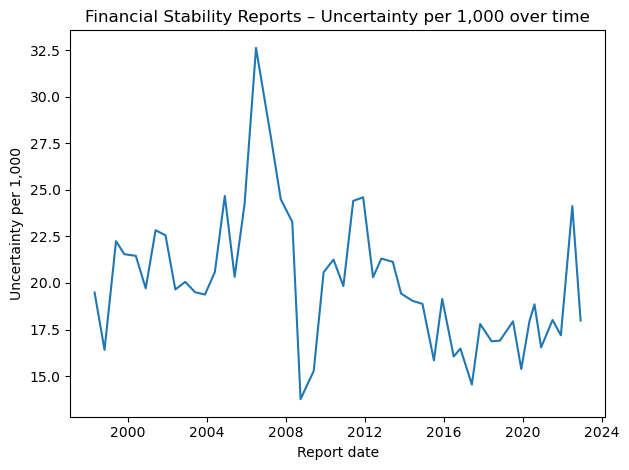

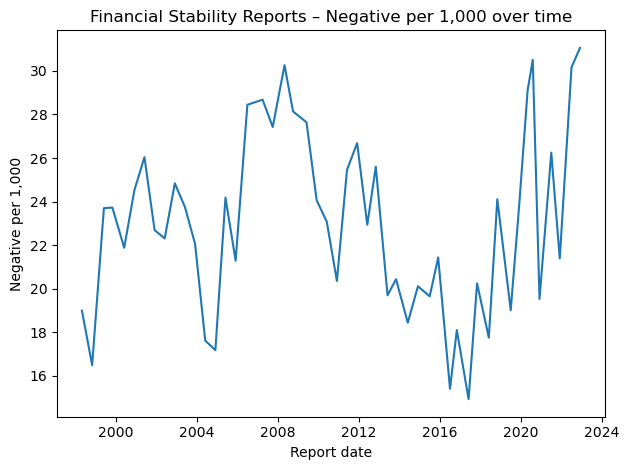

Charts saved to: outputs


In [10]:
import matplotlib.pyplot as plt
from pathlib import Path

# ensure output directory exists
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

x = df_summary.dropna(subset=["report_date"]).sort_values("report_date")

# Uncertainty per 1,000
plt.figure()
plt.plot(x["report_date"], x["uncertainty_per_1000"])
plt.title("Financial Stability Reports – Uncertainty per 1,000 over time")
plt.xlabel("Report date")
plt.ylabel("Uncertainty per 1,000")
plt.tight_layout()
plt.savefig(OUT_DIR / "fsr_uncertainty_per_1000.png", dpi=300)
plt.show()

# Negative per 1,000
plt.figure()
plt.plot(x["report_date"], x["negative_per_1000"])
plt.title("Financial Stability Reports – Negative per 1,000 over time")
plt.xlabel("Report date")
plt.ylabel("Negative per 1,000")
plt.tight_layout()
plt.savefig(OUT_DIR / "fsr_negative_per_1000.png", dpi=300)
plt.show()

print("Charts saved to:", OUT_DIR)

## Step 5: Overall sentiment over time

We summarise tone using two indices:

1) Net Sentiment = (Positive - Negative) / (Positive + Negative)  
   • < 0 → negative language outweighs positive

2) Net Strength = (Strong - Weak) / (Strong + Weak)  
   • > 0 → more forceful than tentative language

We’ll look at:
- Yearly medians (to smooth noise)
- A simple 3-report rolling view on the raw sequence

In [11]:
# Yearly medians for both indices
trend = (
    df_summary.dropna(subset=["year"])
    .groupby("year", as_index=False)[["net_sent_index","net_strength_index"]]
    .median()
    .sort_values("year"))

display(trend.tail(12))  # recent years at a glance

,year,net_sent_index,net_strength_index
13,2011,-0.406115,-0.730965
14,2012,-0.327367,-0.596341
15,2013,-0.252400,-0.503893
16,2014,-0.226562,-0.353729
17,2015,-0.331478,-0.319872
18,2016,-0.310777,-0.450288
19,2017,-0.272218,-0.249990
20,2018,-0.364471,-0.281151
21,2019,-0.329998,-0.196187
22,2020,-0.561564,-0.539726


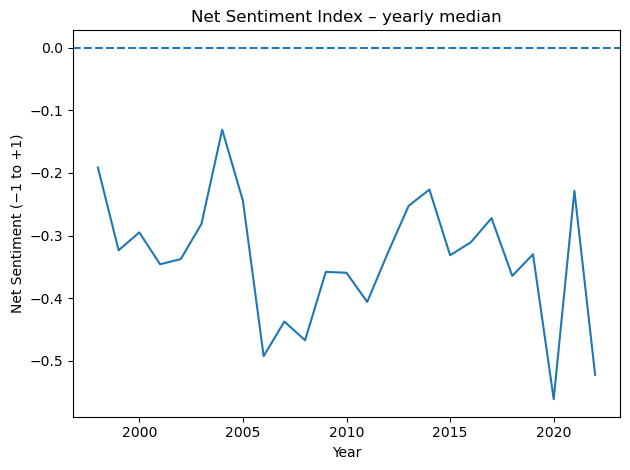

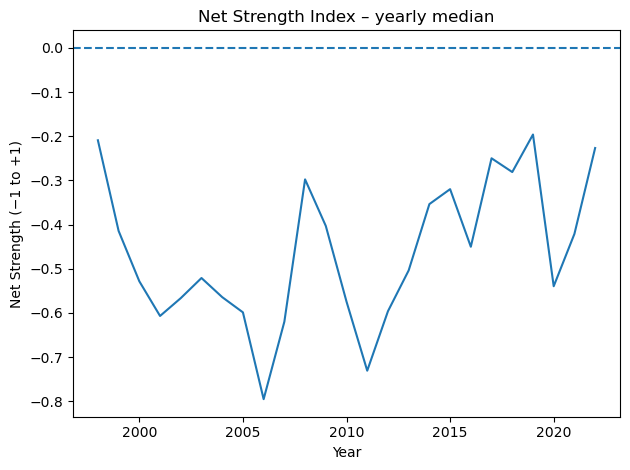

Charts saved to: outputs


In [13]:
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Net Sentiment (yearly median)
plt.figure()
plt.plot(trend["year"], trend["net_sent_index"])
plt.axhline(0, linestyle="--")
plt.title("Net Sentiment Index – yearly median")
plt.xlabel("Year")
plt.ylabel("Net Sentiment (−1 to +1)")
plt.tight_layout()
plt.savefig(OUT_DIR / "fsr_net_sentiment_yearly_median.png", dpi=300)
plt.show()

# Net Strength (yearly median)
plt.figure()
plt.plot(trend["year"], trend["net_strength_index"])
plt.axhline(0, linestyle="--")
plt.title("Net Strength Index – yearly median")
plt.xlabel("Year")
plt.ylabel("Net Strength (−1 to +1)")
plt.tight_layout()
plt.savefig(OUT_DIR / "fsr_net_strength_yearly_median.png", dpi=300)
plt.show()

print("Charts saved to:", OUT_DIR)

>Both indices remain below zero across the full period, which is expected for *Financial Stability Reports*.

>**Why Net Sentiment is negative:**  
>- The reports are written in a **risk-focused** tone: they highlight vulnerabilities, exposures, and potential shocks rather than positive developments.  
>- The **Loughran-McDonald** dictionary itself is finance-specific and risk-tilted - it includes far more negative than positive terms (≈2,300 vs ≈350).  
>- Empirically, negative terms such as *risk*, *loss*, *default*, and *crisis* occur several times more often than positive terms like *growth* or *recovery*.
>
>**Why Net Strength is negative:**  
>- Central bank language is **deliberately cautious** and measured.  
>- Reports use conditional or probabilistic expressions (“may”, “could”, “might”) far more than assertive ones (“must”, “will”).  
>- This communication style leads to more “weak” than “strong” words in the LM categories.
>
>**Trends over time:**  
>- **2007-09:** pronounced troughs reflect the Global Financial Crisis.  
>- **2020-22:** further dips correspond to the COVID-19 shock, Russia's invasion of Ukraine and the LDI-related gilt market stress.  
>- Periods of relative recovery (e.g., 2013-2018) show modest improvements in both indices but still remain below zero, consistent with a prudential and monitoring role rather than an optimistic narrative.
>
>**Key takeaway:**  
>The persistent negative sentiment does not imply bias; it captures the Bank’s institutional focus on identifying and communicating financial risks. These results therefore provide a meaningful quantitative reflection of the stability environment and the Bank’s communication stance over time.

## Step 6: Add VADER sentiment on the same texts

Goal
- Score each Financial Stability Report with **VADER** (pos/neu/neg/compound).
- Merge VADER results with our LM table.
- Produce the same style charts (time series + yearly medians) and a clear LM vs VADER comparison.
- Save everything to `outputs/` (CSV + PNGs).

In [16]:
# Install VADER if needed, then initialise the analyzer
import sys, subprocess, nltk
try:
    from nltk.sentiment import SentimentIntensityAnalyzer
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])
    from nltk.sentiment import SentimentIntensityAnalyzer

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon")

vader = SentimentIntensityAnalyzer()
print("VADER is ready.")

VADER is ready.


### Helper functions

- `chunk_words(text, n)`: split long text into ~n-word chunks.
- `score_vader(text)`: length-weighted average of VADER scores across chunks.
(We reuse `extract_text_from_pdf` and `normalise_text` from earlier.)

In [17]:
def chunk_words(text: str, words_per_chunk: int = 400):
    ws = text.split()
    if not ws:
        return []
    return [" ".join(ws[i:i+words_per_chunk]) for i in range(0, len(ws), words_per_chunk)]

def score_vader(text: str):
    chunks = chunk_words(text, 400)
    if not chunks:
        return {"vader_pos": 0.0, "vader_neu": 0.0, "vader_neg": 0.0, "vader_compound": 0.0}
    totals = {"pos":0.0, "neu":0.0, "neg":0.0, "compound":0.0}
    weight = 0
    for c in chunks:
        w = max(1, len(c.split()))
        s = vader.polarity_scores(c)
        totals["pos"] += s["pos"] * w
        totals["neu"] += s["neu"] * w
        totals["neg"] += s["neg"] * w
        totals["compound"] += s["compound"] * w
        weight += w
    return {
        "vader_pos": totals["pos"]/weight,
        "vader_neu": totals["neu"]/weight,
        "vader_neg": totals["neg"]/weight,
        "vader_compound": totals["compound"]/weight,}

### Score all FSR PDFs with VADER and merge with our LM summary

- Reads each PDF, reuses our normalisation, computes VADER scores.
- Merges into `df_summary` and saves: `outputs/fs_documents_summary_with_vader.csv`.

In [18]:
from pathlib import Path
import pandas as pd

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PDF_FOLDER = Path("pdfs/financial_stability")
pdf_files = sorted(PDF_FOLDER.glob("*.pdf"))

# Load the LM summary if not in memory
if "df_summary" not in globals():
    df_summary = pd.read_csv(OUT_DIR / "fs_documents_summary.csv")

v_rows = []
for p in pdf_files:
    print("VADER scoring:", p.name)
    raw = extract_text_from_pdf(p)
    norm = normalise_text(raw)
    v_rows.append({"document": p.stem, **score_vader(norm)})

df_vader = pd.DataFrame(v_rows)
df_models = df_summary.merge(df_vader, on="document", how="left")

# Ensure date fields exist (if not already added earlier)
if "report_date" not in df_models.columns:
    name_upper = df_models["document"].str.upper()
    month_map = {
        "JANUARY":1,"FEBRUARY":2,"MARCH":3,"APRIL":4,"MAY":5,"JUNE":6,
        "JULY":7,"AUGUST":8,"SEPTEMBER":9,"OCTOBER":10,"NOVEMBER":11,"DECEMBER":12}
    df_models["year"] = pd.to_numeric(name_upper.str.extract(r"(\d{4})", expand=False), errors="coerce")
    df_models["month_name"] = name_upper.str.extract(
        r"(JANUARY|FEBRUARY|MARCH|APRIL|MAY|JUNE|JULY|AUGUST|SEPTEMBER|OCTOBER|NOVEMBER|DECEMBER)",
        expand=False)
    df_models["month"] = df_models["month_name"].map(month_map)
    df_models["report_date"] = pd.to_datetime(
        dict(year=df_models["year"], month=df_models["month"].fillna(12), day=1),
        errors="coerce")

df_models = df_models.sort_values("report_date").reset_index(drop=True)
df_models.to_csv(OUT_DIR / "fs_documents_summary_with_vader.csv", index=False)
print("Saved:", OUT_DIR / "fs_documents_summary_with_vader.csv")
df_models.head(3)

VADER scoring: FSR-APRIL-2007.pdf
VADER scoring: FSR-AUGUST-2020.pdf
VADER scoring: FSR-DECEMBER-2000.pdf
VADER scoring: FSR-DECEMBER-2001.pdf
VADER scoring: FSR-DECEMBER-2002.pdf
VADER scoring: FSR-DECEMBER-2003.pdf
VADER scoring: FSR-DECEMBER-2004.pdf
VADER scoring: FSR-DECEMBER-2005.pdf
VADER scoring: FSR-DECEMBER-2009.pdf
VADER scoring: FSR-DECEMBER-2010.pdf
VADER scoring: FSR-DECEMBER-2011.pdf
VADER scoring: FSR-DECEMBER-2014.pdf
VADER scoring: FSR-DECEMBER-2015.pdf
VADER scoring: FSR-DECEMBER-2019.pdf
VADER scoring: FSR-DECEMBER-2020.pdf
VADER scoring: FSR-DECEMBER-2021.pdf
VADER scoring: FSR-DECEMBER-2022.pdf
VADER scoring: FSR-JULY-2006.pdf
VADER scoring: FSR-JULY-2015.pdf
VADER scoring: FSR-JULY-2016.pdf
VADER scoring: FSR-JULY-2019.pdf
VADER scoring: FSR-JULY-2021.pdf
VADER scoring: FSR-JULY-2022.pdf
VADER scoring: FSR-JUNE-1999.pdf
VADER scoring: FSR-JUNE-2000.pdf
VADER scoring: FSR-JUNE-2001.pdf
VADER scoring: FSR-JUNE-2002.pdf
VADER scoring: FSR-JUNE-2003.pdf
VADER scoring

,section,document,tokens_total,positive_per_1000,negative_per_1000,uncertainty_per_1000,litigious_per_1000,constraining_per_1000,strong_per_1000,weak_per_1000,net_sent_index,net_strength_index,matched_per_1000,year,month_name,month,report_date,vader_pos,vader_neu,vader_neg,vader_compound
0,financial_stability,FSR-MAY-1998,52023,12.398362,18.991600,19.491379,7.804240,4.671011,4.132787,7.169906,-0.210043,-0.268707,74.659285,1998,MAY,5,1998-05-01,0.092574,0.844813,0.062636,0.513869
1,financial_stability,FSR-NOVEMBER-1998,49311,11.640405,16.487194,16.406076,6.854454,4.643994,4.319523,5.840482,-0.172314,-0.149701,66.192128,1998,NOVEMBER,11,1998-11-01,0.099064,0.848949,0.051989,0.596387
2,financial_stability,FSR-JUNE-1999,90211,13.080445,23.699992,22.247841,7.238585,4.101495,3.270111,7.260755,-0.288728,-0.378947,80.899225,1999,JUNE,6,1999-06-01,0.094824,0.845001,0.060130,0.552576


### VADER charts

1) VADER compound over time (line).
2) VADER compound - yearly median (line).
Files saved into `outputs/`.

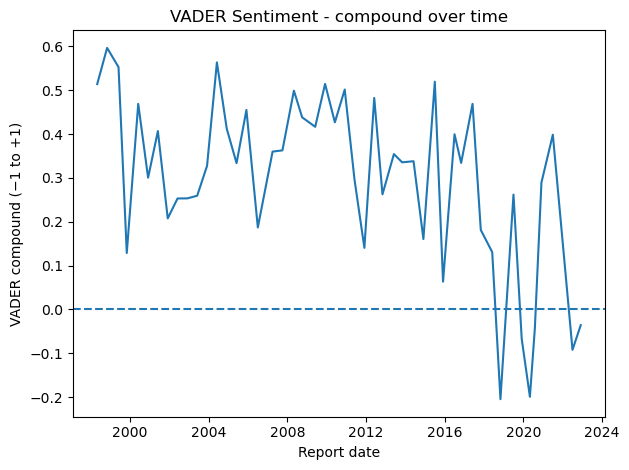

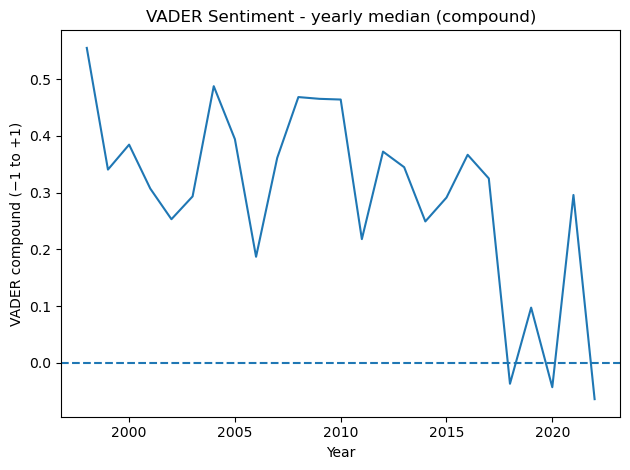

Charts saved to: outputs


In [20]:
import matplotlib.pyplot as plt

z = df_models.dropna(subset=["report_date","vader_compound"]).sort_values("report_date")

# Time series
plt.figure()
plt.plot(z["report_date"], z["vader_compound"])
plt.axhline(0, linestyle="--")
plt.title("VADER Sentiment - compound over time")
plt.xlabel("Report date")
plt.ylabel("VADER compound (−1 to +1)")
plt.tight_layout()
plt.savefig(OUT_DIR / "fsr_vader_compound_over_time.png", dpi=300)
plt.show()

# Yearly medians
trend_vader = (
    df_models.dropna(subset=["year","vader_compound"])
    .groupby("year", as_index=False)["vader_compound"]
    .median()
    .sort_values("year"))

plt.figure()
plt.plot(trend_vader["year"], trend_vader["vader_compound"])
plt.axhline(0, linestyle="--")
plt.title("VADER Sentiment - yearly median (compound)")
plt.xlabel("Year")
plt.ylabel("VADER compound (−1 to +1)")
plt.tight_layout()
plt.savefig(OUT_DIR / "fsr_vader_compound_yearly_median.png", dpi=300)
plt.show()

print("Charts saved to:", OUT_DIR)

> Across the full period, VADER sentiment remains **consistently positive**, with scores fluctuating between moderate optimism and neutrality.  
> Unlike the LM dictionary, which reflects a risk-based perspective, VADER captures a more *surface-level sentiment*, interpreting the formal and measured language of the Bank as generally reassuring rather than cautious.
> 
> **Overall tone:**  
> The results portray the Financial Stability Reports as **confident, steady, and stable in tone**.  
> This is not surprising: the language used in these reports frequently emphasises resilience, robustness, and system preparedness, which VADER interprets as positive expressions.  
> Periods of stress (such as 2008–09, 2020, and 2022) still register dips, but sentiment remains largely above neutral, suggesting that even in crisis years the reports maintain a composed and reassuring communication style.
> 
> **Trends over time:**  
> - **Pre-2008:** High positive readings reflect the confidence and stability that characterised the pre-crisis environment.  
> - **2008-09:** A visible decline coincides with the Global Financial Crisis, although the tone remains more measured than alarmist.  
> - **2010-2018:** Sentiment stabilises again, mirroring the gradual economic recovery and the strengthening of financial system safeguards.  
> - **2020-22:** Temporary drops align with global shocks (COVID-19, the Ukraine war, and the LDI crisis) yet sentiment quickly returns to positive territory, reflecting the Bank’s emphasis on stability and control.
> 
> The overall pattern suggests that the Bank’s communication, when viewed through a general sentiment lens, is **reassuring rather than pessimistic**.  
> Even during crises, the tone remains anchored in stability and confidence, underlining the Bank’s role as a steadying voice in turbulent times.  
> In contrast to the LM results, which expose the underlying risk language and caution inherent in the reports, VADER highlights the **outward tone** - measured, confident, and calm - that the Bank consistently projects to maintain trust and assurance.

### Compare LM vs VADER (saved)

We’ll create:
- Yearly median comparison on one chart.
Files saved into `outputs/`.

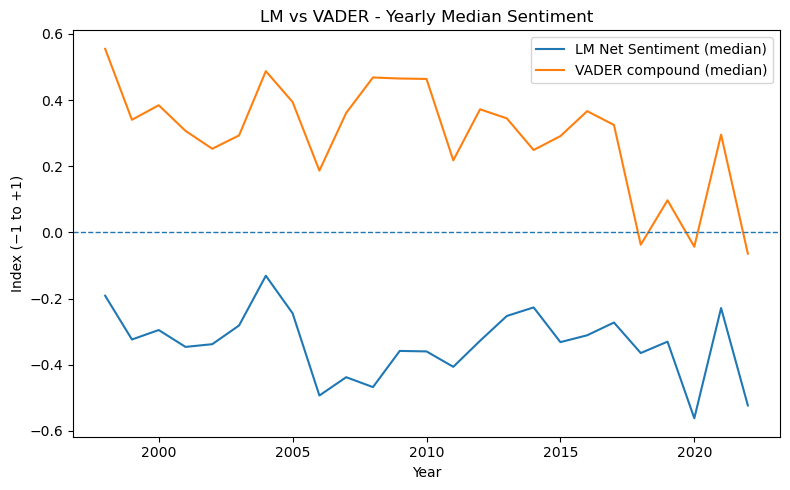

Chart saved to: outputs/fsr_lm_vs_vader_yearly_medians.png


In [25]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Compute yearly medians for LM and VADER
trend_lm = (
    df_models.dropna(subset=["year", "net_sent_index"])
    .groupby("year", as_index=False)["net_sent_index"]
    .median()
    .rename(columns={"net_sent_index": "lm_net_sent_median"}))

trend_vader = (
    df_models.dropna(subset=["year", "vader_compound"])
    .groupby("year", as_index=False)["vader_compound"]
    .median()
    .rename(columns={"vader_compound": "vader_compound_median"}))

# --- Merge and plot
trend_cmp = trend_lm.merge(trend_vader, on="year", how="outer").sort_values("year")

plt.figure(figsize=(8,5))
plt.plot(trend_cmp["year"], trend_cmp["lm_net_sent_median"], label="LM Net Sentiment (median)")
plt.plot(trend_cmp["year"], trend_cmp["vader_compound_median"], label="VADER compound (median)")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("LM vs VADER - Yearly Median Sentiment")
plt.xlabel("Year")
plt.ylabel("Index (−1 to +1)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fsr_lm_vs_vader_yearly_medians.png", dpi=300)
plt.show()

print("Chart saved to:", OUT_DIR / "fsr_lm_vs_vader_yearly_medians.png")

> ### Yearly Median Sentiment (LM vs VADER)
> 
> This comparison captures two very different dimensions of the Bank of England’s Financial Stability Reports; the **substance** of what is said (LM) and the **tone** in which it is communicated (VADER).
> 
> **1. Overall patterns**  
The **LM sentiment** remains consistently below zero across the entire period, confirming that the underlying language of the reports is inherently **risk-focused**.  
> These are documents designed to identify vulnerabilities, exposures, and potential threats to stability; not to convey optimism.  
> In contrast, the **VADER sentiment** stays mostly **positive**, reflecting the Bank’s formal, measured, and reassuring communication style. Even when the content deals with systemic risk, the tone remains steady and composed.
> 
> **2. Alignment over time**  
Despite their different baselines, the two measures move largely **in the same direction** through key episodes:
> - **2007-09 (Global Financial Crisis):** Both lines dive sharply (LM turning deeply negative, VADER dropping towards neutral), capturing the severity of the shock and the Bank’s cautious but controlled tone.  
> - **2011-12 (Euro-area and UK slowdown):** A smaller joint dip mirrors renewed global uncertainty and market fragility.  
> - **2013-2018 (Recovery and reform):** Both indices rise (LM becomes less negative, VADER remains stably positive)- showing a calmer, more confident tone as regulation and resilience strengthen.  
> - **2020-22 (COVID-19, Ukraine war, and LDI stress):** The sharpest simultaneous downturn since 2008. LM records its lowest values, reflecting high-risk language; VADER slips towards or just below zero, signalling a more openly cautious tone.
> 
> **3. What this tells us**  
> The **directional alignment** between the two lines shows that both models are detecting real shifts in sentiment; they react to the same underlying events and inflection points in the economic environment.  
> The **gap** between them, however, is the insight:  
> - LM captures the Bank’s **internal caution:** the vocabulary of risk assessment.  
> - VADER captures the Bank’s **external voice:** the communication of stability and control.  
> 
> Together, they depict an institution that consistently balances honesty about risk with the need to project confidence.  
> When sentiment turns sharply negative in LM and softens in VADER, it’s not a contradiction; it’s the Bank performing its dual role: **acknowledging fragility while reassuring the public that the system remains under control.**
> 
> **4. Key takeaway**  
> Across twenty-five years of reports, the picture is remarkably consistent:  
> - **Cautious in substance, calm in tone.**  
> - LM reflects the analytic language of risk; VADER reflects the communicative language of reassurance.  
> The interplay between the two is precisely what you would expect from a central bank charged with maintaining both **financial stability** and **public confidence.**

<div class="alert alert-block alert-info">
Notebook End